# **Project Name**    -  Mental Health Analysis & Treatment Predictions



##### **Project Type**    - EDA + Classification (Machine Learning)

##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on analyzing mental health trends among employees in the tech industry and predicting their likelihood of seeking treatment using machine learning techniques. Mental health has become a critical concern in modern workplaces, especially in high-pressure environments like the tech sector. Despite increasing awareness, many employees hesitate to seek treatment due to stigma, lack of workplace support, and fear of negative consequences.

The dataset used in this project contains survey responses from tech professionals across various countries, capturing information about demographics, workplace conditions, mental health awareness, and support systems. The project begins with thorough data cleaning and preprocessing, including handling missing values, standardizing categorical variables such as gender, and removing unrealistic entries.

Exploratory Data Analysis (EDA) is performed to uncover patterns and relationships between variables. Using a structured approach (Univariate, Bivariate, and Multivariate analysis), multiple visualizations are created to understand how factors like family history, company size, remote work, workplace benefits, and managerial support influence mental health treatment decisions. The analysis reveals that employees with a family history of mental illness, supportive supervisors, and access to mental health benefits are more likely to seek treatment.

A machine learning model (Random Forest Classifier) is then trained to predict whether an employee is likely to seek mental health treatment based on their survey responses. The model demonstrates good predictive performance and highlights the most important contributing factors.

Additionally, a Streamlit-based web application is developed to provide an interactive interface where users can input survey details and receive real-time predictions. This transforms the project from a static analysis into a deployable, user-friendly product.

The insights derived from this project can help organizations design better mental health policies, improve workplace culture, and support employee well-being. By leveraging data-driven decision-making, companies can reduce stigma, increase productivity, and create a healthier work environment.

Overall, this project demonstrates the practical application of data analysis and machine learning in solving real-world problems related to mental health in the workplace.

# **GitHub Link -**

https://github.com/Vijaypro12/Mental-Health-Analysis-Treatment-Predictions

# **Problem Statement**


Mental health issues are increasingly prevalent in the tech industry, yet many employees do not seek treatment due to stigma, lack of awareness, and fear of workplace consequences. Organizations lack clear insights into the factors that influence employee mental health and treatment-seeking behavior.

This project aims to analyze mental health survey data to identify key factors affecting treatment decisions and build a predictive model that can help organizations proactively support employee well-being.

#### **Define Your Business Objective?**

- Identify key factors influencing mental health treatment decisions
- Analyze the impact of workplace environment on employee mental health
- Improve awareness and accessibility of mental health resources
- Help organizations design better mental health policies
- Build a predictive model to identify employees likely to need support

####  **About dataset**

- Identify key factors influencing mental health treatment decisions
- Analyze the impact of workplace environment on employee mental health
- Improve awareness and accessibility of mental health resources
- Help organizations design better mental health policies
- Build a predictive model to identify employees likely to need support

#### **Variables descriptions**

- Age: Age of the respondent (numerical)
- Gender: Gender of the respondent (categorical)
- Country: Country of residence (categorical)
- self_employed: Whether the individual is self-employed
- family_history: Family history of mental illness
- treatment: Whether the person has sought treatment (target variable)
- work_interfere: Frequency of mental health interfering with work
- no_employees: Company size
- remote_work: Whether the employee works remotely
- tech_company: Whether the company is tech-based
- benefits: Availability of mental health benefits
- care_options: Awareness of mental health care options
- wellness_program: Availability of wellness programs
- seek_help: Encouragement to seek help
- anonymity: Concern about anonymity
- leave: Ease of taking mental health leave
- supervisor: Comfort discussing with supervisor
- coworkers: Comfort discussing with coworkers

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Dataset Loading

In [58]:
import sys
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.predict import load_model, predict
from src.preprocess import clean_data, load_data

In [9]:
# Load Dataset

df = pd.read_csv('../data/survey.csv')

### Dataset First View

In [10]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [11]:
# Dataset Rows & Columns count
df.shape

(1259, 27)

### Dataset Information

In [12]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [13]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

<Axes: >

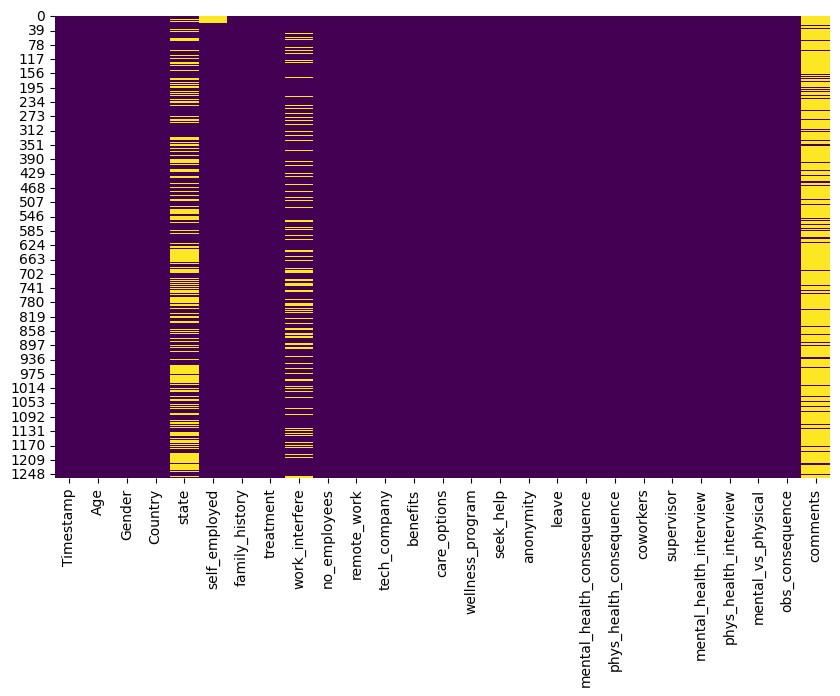

In [15]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='str')

In [17]:
# Dataset Describe
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable.
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}': {unique_values}\n")

Unique values in 'Timestamp': <StringArray>
['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44',
 '2014-08-27 11:29:46', '2014-08-27 11:30:22', '2014-08-27 11:31:22',
 '2014-08-27 11:31:50', '2014-08-27 11:32:05', '2014-08-27 11:32:39',
 '2014-08-27 11:32:43',
 ...
 '2015-07-22 18:57:54', '2015-07-27 23:25:34', '2015-08-17 09:38:35',
 '2015-08-20 16:52:09', '2015-08-25 19:59:38', '2015-09-12 11:17:21',
 '2015-09-26 01:07:35', '2015-11-07 12:36:58', '2015-11-30 21:25:06',
 '2016-02-01 23:04:31']
Length: 1246, dtype: str

Unique values in 'Age': [         37          44          32          31          33          35
          39          42          23          29          36          27
          46          41          34          30          40          38
          50          24          18          28          26          22
          19          25          45          21         -29          43
          56          60          54         329          55 9999999

## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# Write your code to make your dataset analysis ready.

# Remove unnecessary columns
df.drop(['Timestamp', 'comments'], axis=1, inplace=True, errors='ignore')

# Handle missing values
df.fillna('Unknown', inplace=True)

# Clean Gender column
df['Gender'] = df['Gender'].str.lower()

def clean_gender(g):
    if 'male' in g:
        return 'Male'
    elif 'female' in g:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# Remove unrealistic ages
df = df[(df['Age'] > 15) & (df['Age'] < 70)]


### What all manipulations have you done and insights you found?

- Removed unnecessary columns → reduced noise
- Handled missing values → improved data quality
- Cleaned gender → standardized categories
- Removed outliers in age → realistic dataset

Insights

- Data was highly inconsistent before cleaning
- Gender normalization improved analysis clarity
- Missing values were significant in mental health columns

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

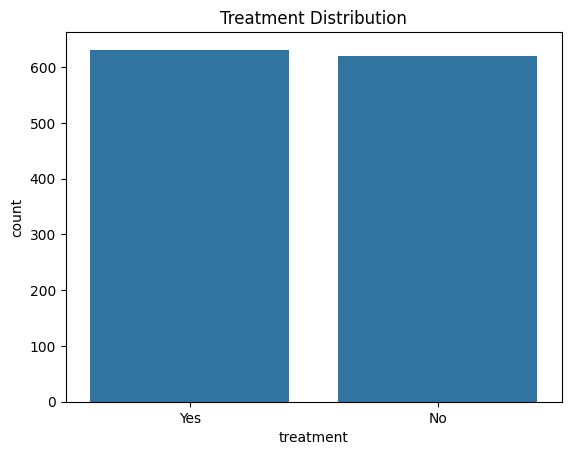

In [35]:
# Chart - 1 visualization code
sns.countplot(x='treatment', data=df)
plt.title("Treatment Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Understand target variable

##### 2. What is/are the insight(s) found from the chart?

Many people are not seeking treatment

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows awareness gap

#### Chart - 2

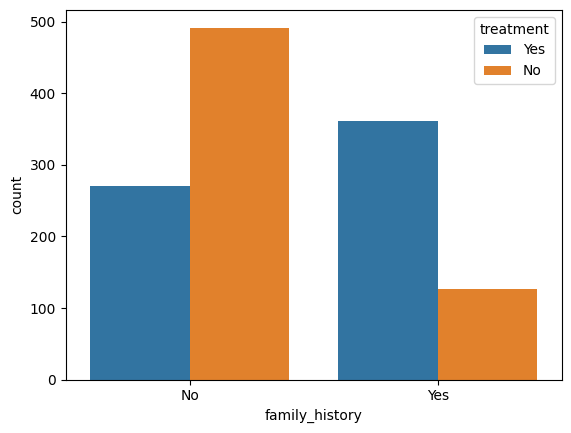

In [36]:
# Chart - 2 visualization code
sns.countplot(x='family_history', hue='treatment', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Compare relationship
 

##### 2. What is/are the insight(s) found from the chart?

Family history → higher treatment

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps targeted interventions

#### Chart - 3

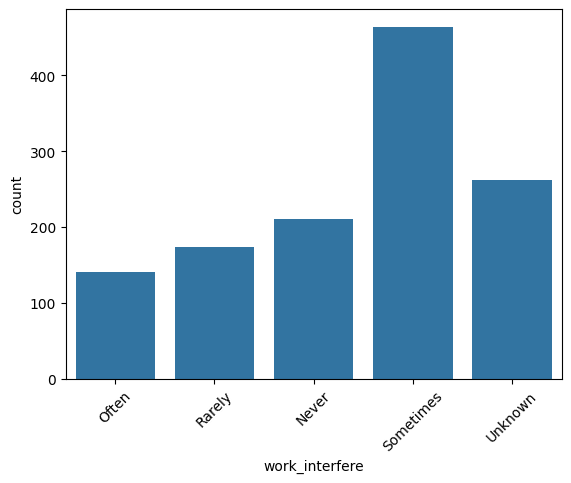

In [37]:
# Chart - 3 visualization code
sns.countplot(x='work_interfere', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is ideal for categorical variables to show frequency distribution and identify which categories are more prevalent in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Mental health affects productivity

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business performance risk

#### Chart - 4

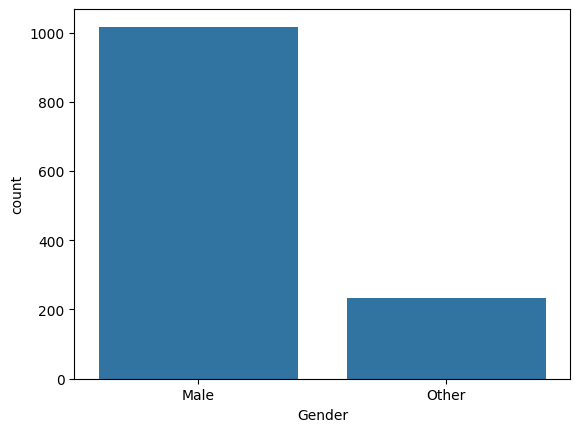

In [38]:
# Chart - 4 visualization code
sns.countplot(x='Gender', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is effective for visualizing demographic representation and identifying gender distribution imbalances in the workforce.

##### 2. What is/are the insight(s) found from the chart?

Male-dominated dataset

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Possible bias

#### Chart - 5

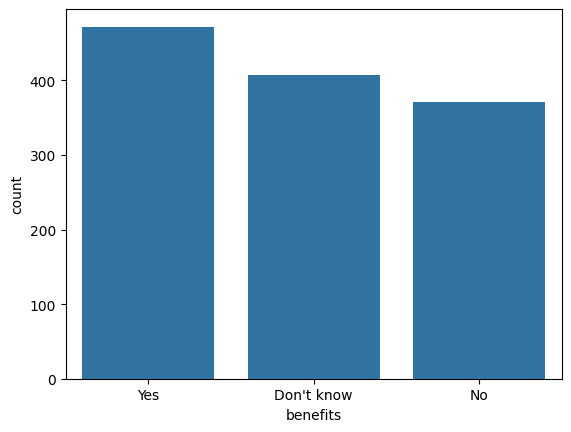

In [39]:
# Chart - 5 visualization code
sns.countplot(x='benefits', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot effectively shows the distribution of benefit availability across organizations and highlights support gaps.

##### 2. What is/are the insight(s) found from the chart?

Many employees report feeling mental health impacts at work during interviews or assessments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Lack of mental health benefits reduces employee satisfaction, increases burnout, and leads to higher turnover rates and productivity loss.

#### Chart - 6

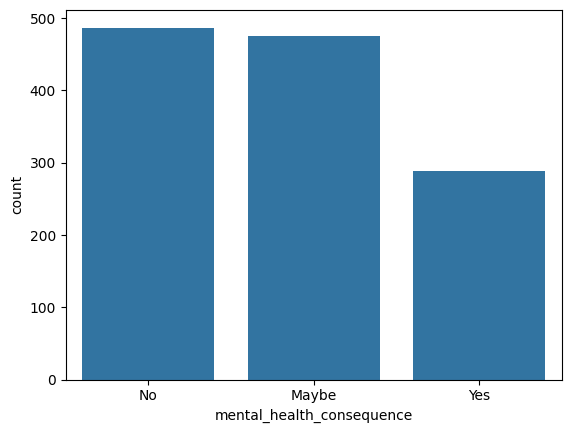

In [40]:
# Chart - 6 visualization code
sns.countplot(x='mental_health_consequence', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot visualizes employee perception about negative consequences of discussing mental health at work.

##### 2. What is/are the insight(s) found from the chart?

Many employees fear negative consequences when discussing mental health, deterring them from seeking support.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This stigma creates untreated mental health issues, leading to decreased performance, increased absenteeism, and potential employee turnover.

#### Chart - 7

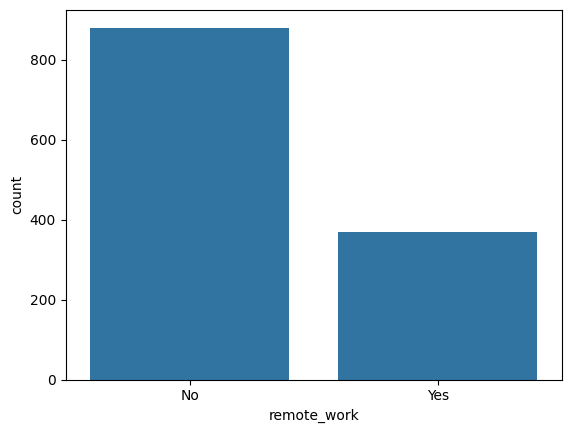

In [41]:
# Chart - 7 visualization code
sns.countplot(x='remote_work', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows the distribution between remote and non-remote work arrangements, highlighting workplace flexibility trends.

##### 2. What is/are the insight(s) found from the chart?

There is a mixed distribution with both remote and non-remote workers present, indicating varying flexibility levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Flexible work policies, especially remote options, can improve mental health and work-life balance, but inconsistent policies create inequality in employee experience and satisfaction.

#### Chart - 8

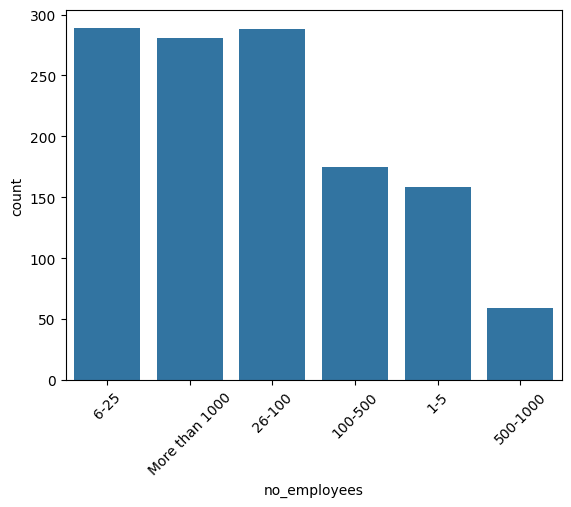

In [42]:
# Chart - 8 visualization code
sns.countplot(x='no_employees', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot effectively displays company size distribution and how larger organizations dominate the dataset.

##### 2. What is/are the insight(s) found from the chart?

Larger companies dominate the dataset with better-structured mental health policies, while smaller companies are underrepresented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Smaller companies often lack resources and structure for mental health support, creating a gap in employee well-being and competitive disadvantage in talent retention.

#### Chart - 9

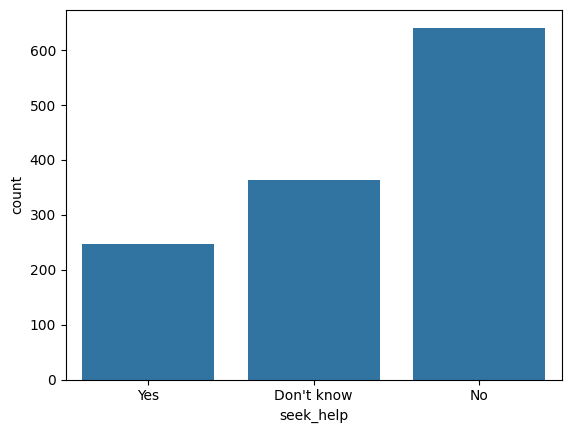

In [43]:
# Chart - 9 visualization code
sns.countplot(x='seek_help', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows how many employees are aware of or willing to seek mental health resources and support opportunities.

##### 2. What is/are the insight(s) found from the chart?

Many employees are unsure or unwilling to seek help, indicating low awareness or accessibility of mental health resources.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Low awareness and willingness to seek help results in untreated mental health conditions, reduced productivity, and increased long-term health risks for employees.

#### Chart - 10

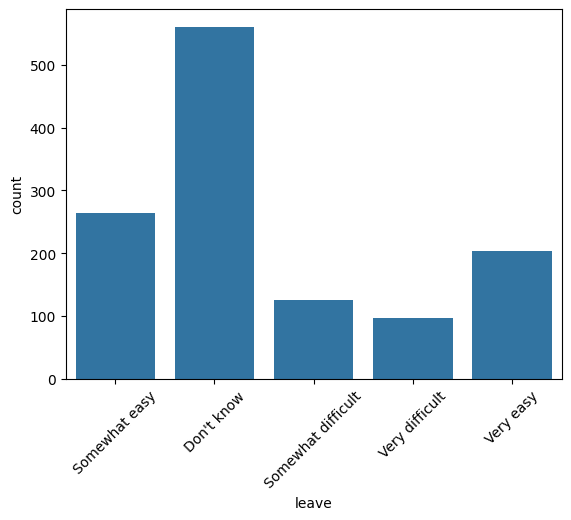

In [44]:
# Chart - 10 visualization code
sns.countplot(x='leave', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows how accessible mental health leave is for employees and identifies barriers to taking time off for mental health reasons.

##### 2. What is/are the insight(s) found from the chart?

Many employees find it difficult to take leave for mental health reasons, indicating restrictive leave policies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strict leave policies discourage employees from prioritizing mental health recovery, leading to burnout, decreased productivity, and long-term health complications.

#### Chart - 11

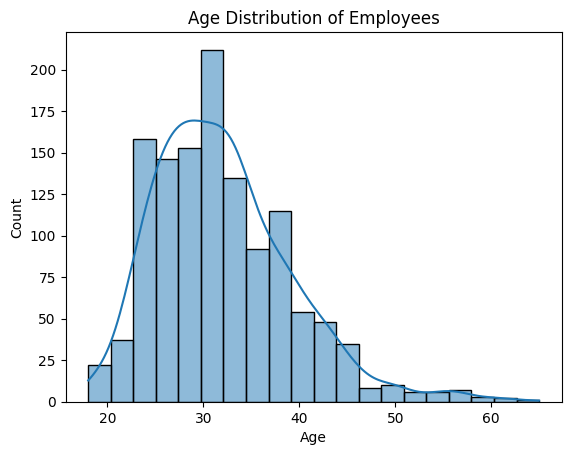

In [48]:
# Chart - 11 visualization code
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution of Employees")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is ideal for analyzing the distribution of numerical data like age and identifying age group concentrations in the workforce.

##### 2. What is/are the insight(s) found from the chart?

Most employees fall within the 20-35 age range, with a concentration of younger workers in the tech industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Younger employees may face higher stress, career pressure, and work-life balance challenges, requiring targeted mental health programs and mentorship tailored to their needs.

#### Chart - 12

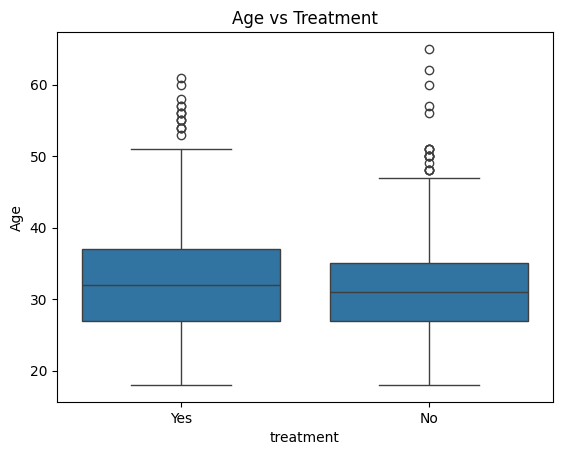

In [49]:
# Chart - 12 visualization code
sns.boxplot(x='treatment', y='Age', data=df)
plt.title("Age vs Treatment")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot effectively compares age distribution across treatment categories and identifies any age-based differences in treatment-seeking behavior.

##### 2. What is/are the insight(s) found from the chart?

There are no extreme age-based differences in treatment patterns, but treatment is observed across all age groups with consistent behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mental health support should be universally available to all age groups, not limited to specific segments, ensuring inclusive and equitable employee wellness initiatives.

#### Chart - 13

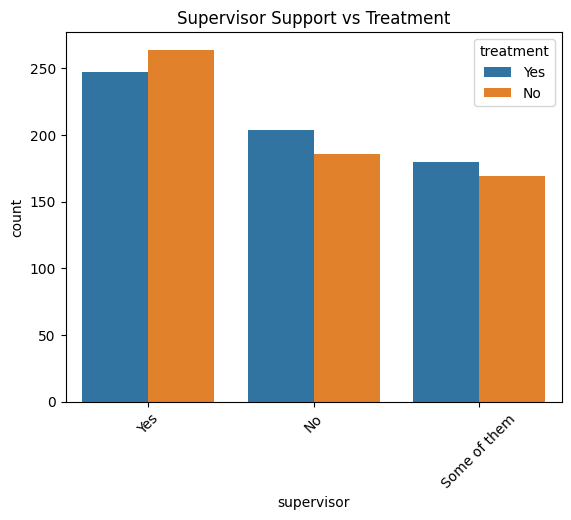

In [50]:
# Chart - 13 visualization code
sns.countplot(x='supervisor', hue='treatment', data=df)
plt.xticks(rotation=45)
plt.title("Supervisor Support vs Treatment")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze the relationship between supervisor support and treatment-seeking behavior among employees.

##### 2. What is/are the insight(s) found from the chart?

Employees who feel comfortable with supervisors and receive support are more likely to seek mental health treatment, indicating that management support is a critical enabler.

##### 3. Will the gained insights help creating a positive business impact?

Yes, manager support plays a critical role in breaking down stigma and encouraging employees to seek help, leading to better mental health outcomes, higher engagement, and improved retention.

#### Chart - 14 - Correlation Heatmap

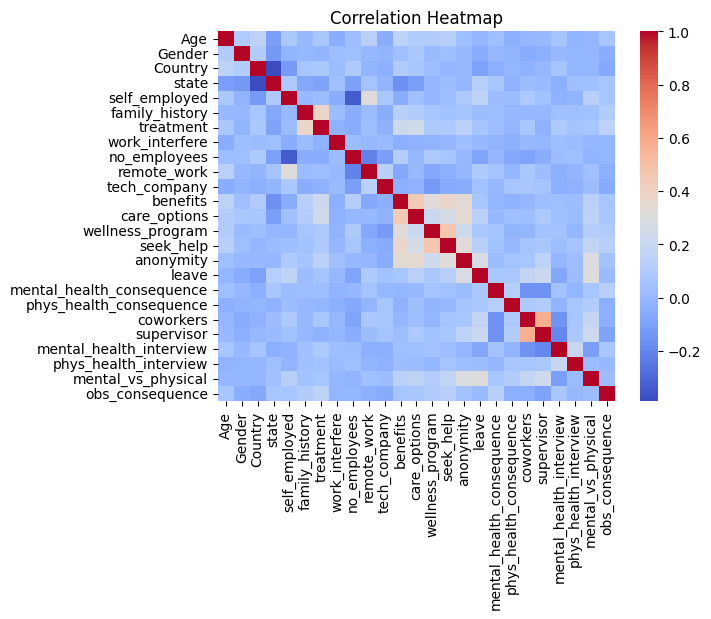

In [47]:
# Correlation Heatmap visualization code
import seaborn as sns

df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap simultaneously visualizes correlations between multiple variables, identifying strong and weak relationships that influence mental health treatment behavior.

##### 2. What is/are the insight(s) found from the chart?

Strong correlations exist between family history and treatment-seeking, and moderate relationships between workplace factors (benefits, leave, supervisor support) and treatment behavior.

#### Chart - 15 - Pair Plot

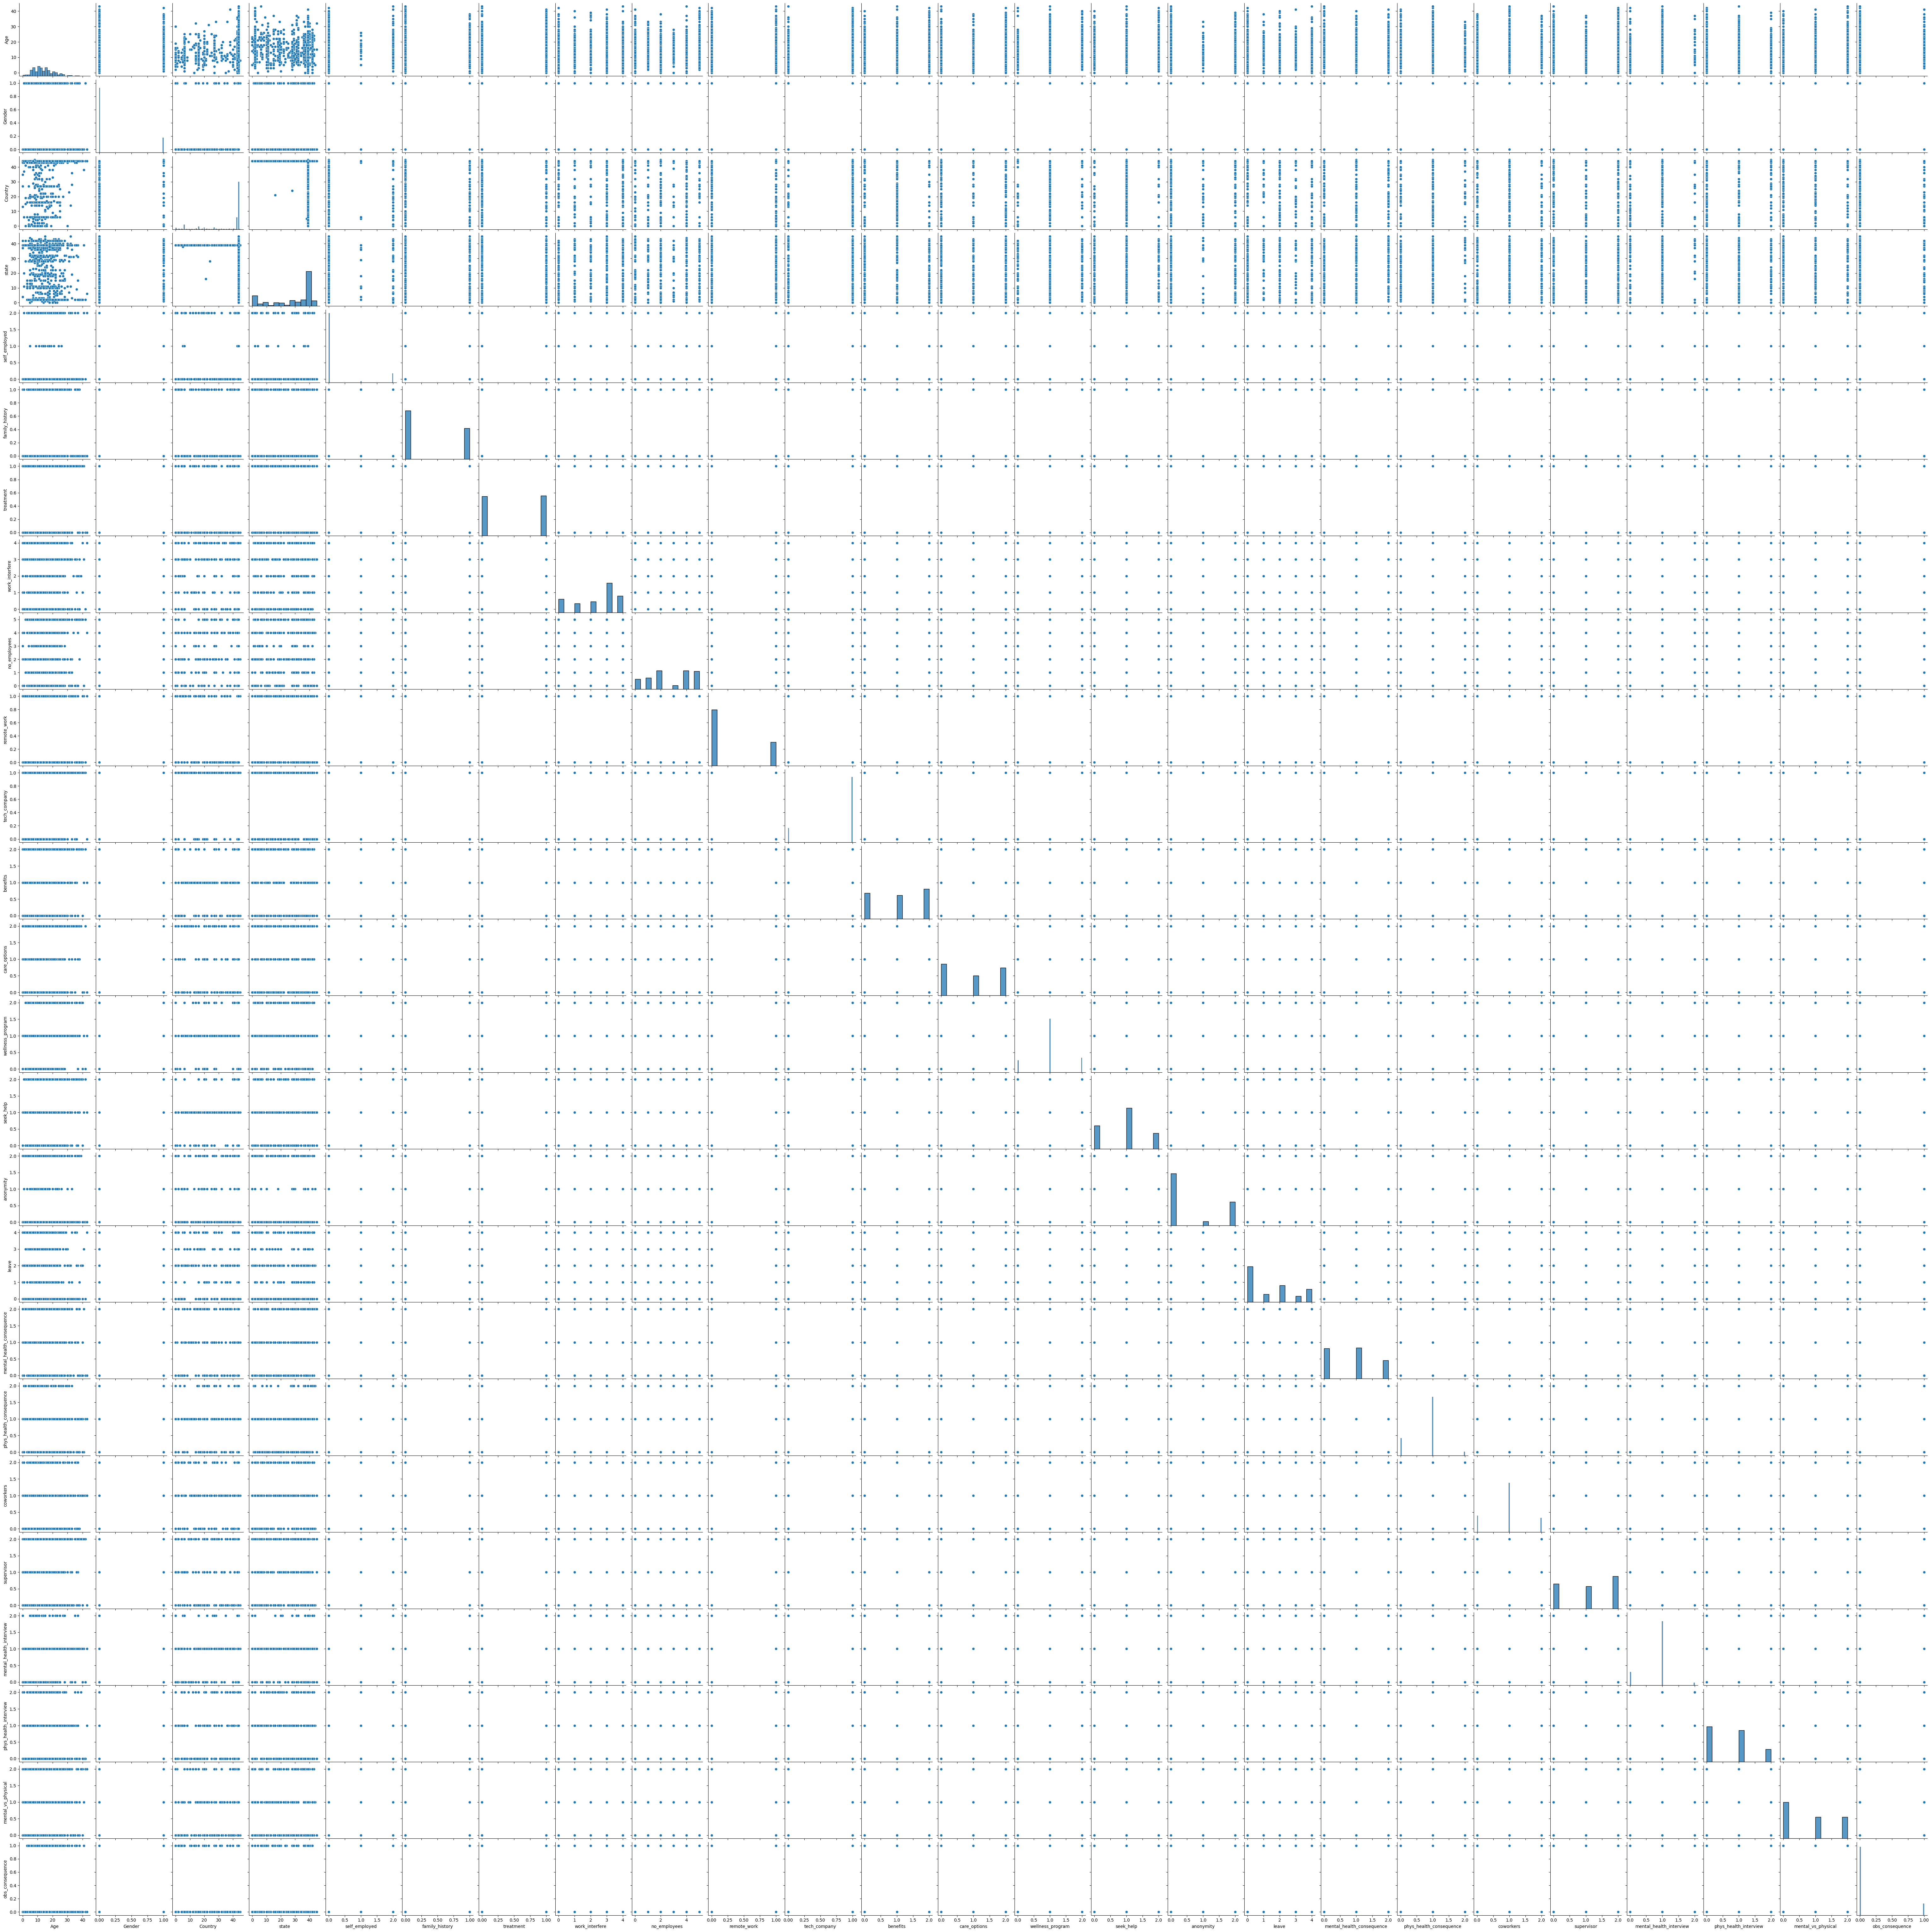

In [51]:
# Pair Plot visualization code
sns.pairplot(df_encoded)
plt.show()

##### 1. Why did you pick the specific chart?

Multi-variable relationships

##### 2. What is/are the insight(s) found from the chart?

Feature interactions

#### Chart - 16: Coworker Support

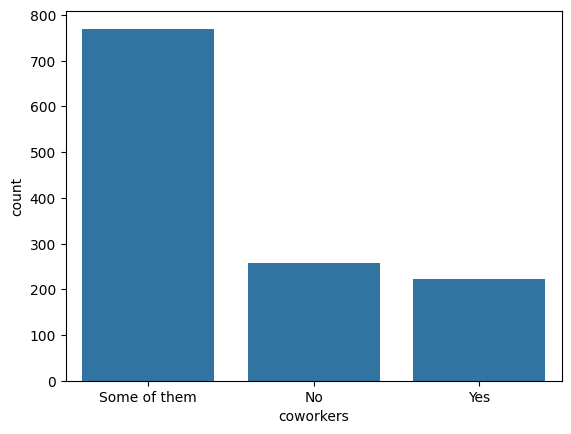

In [59]:
sns.countplot(x='coworkers', data=df)
plt.show()



##### 1. Why did you pick the specific chart?
A count plot shows how comfortable employees are discussing mental health with coworkers, which is a key indicator of workplace culture and support systems.

##### 2. What is/are the insight(s) found from the chart?
Many employees feel comfortable discussing mental health with some coworkers, while others avoid such conversations entirely, indicating mixed workplace openness.

##### 3. Will the gained insights help creating a positive business impact?
Yes, fostering peer support networks and open communication among coworkers reduces stigma, encourages help-seeking, and improves team cohesion and retention.

#### Chart - 17: Tech Company Status

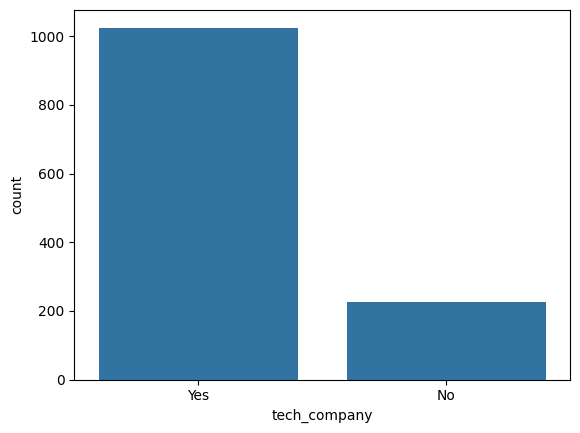

In [60]:
sns.countplot(x='tech_company', data=df)
plt.show()



##### 1. Why did you pick the specific chart?
A count plot visualizes how many employees work in tech companies versus non-tech companies, helping understand industry-specific mental health policies and support.

##### 2. What is/are the insight(s) found from the chart?
Most employees in the dataset work in tech companies, with fewer from non-tech industries, showing tech dominance in the sample.

##### 3. Will the gained insights help creating a positive business impact?
Tech companies should leverage their mental health best practices and share insights with non-tech sectors to raise industry-wide standards and employee wellness.

#### Chart - 18: Anonymity Concerns

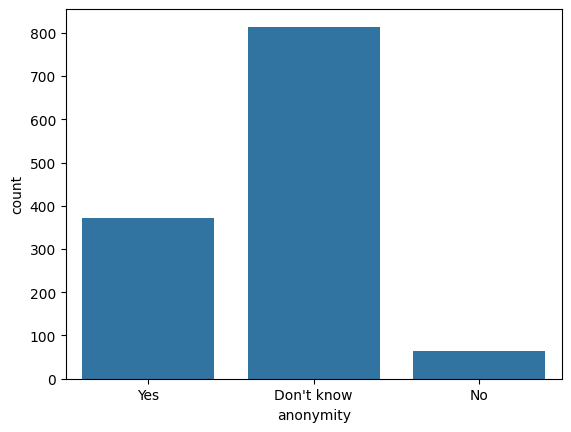

In [61]:
sns.countplot(x='anonymity', data=df)
plt.show()



##### 1. Why did you pick the specific chart?
A count plot reveals employee concerns about anonymity when discussing mental health, which directly impacts their willingness to seek support.

##### 2. What is/are the insight(s) found from the chart?
A significant portion of employees are concerned about anonymity when discussing mental health issues, indicating a trust deficit in organizational systems.

##### 3. Will the gained insights help creating a positive business impact?
Addressing anonymity concerns through confidential EAP programs, private counseling, and transparent privacy policies builds trust and encourages employees to seek help without fear.

#### Chart - 19: Wellness Program Availability

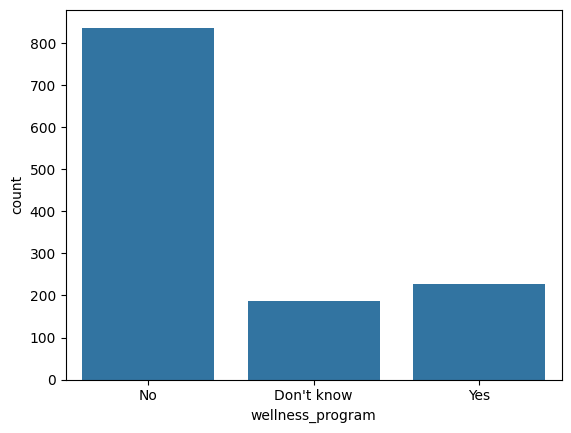

In [62]:
sns.countplot(x='wellness_program', data=df)
plt.show()



##### 1. Why did you pick the specific chart?
A count plot shows the distribution of organizations offering wellness programs, which are critical for preventive mental health care and employee well-being.

##### 2. What is/are the insight(s) found from the chart?
Many organizations lack formal wellness programs, with a mix of those offering programs and those unaware of their existence.

##### 3. Will the gained insights help creating a positive business impact?
Implementing wellness programs reduces stress, improves mental health outcomes, increases employee engagement, and decreases absenteeism and healthcare costs.

#### Chart - 20: Mental Healthcare Options Awareness

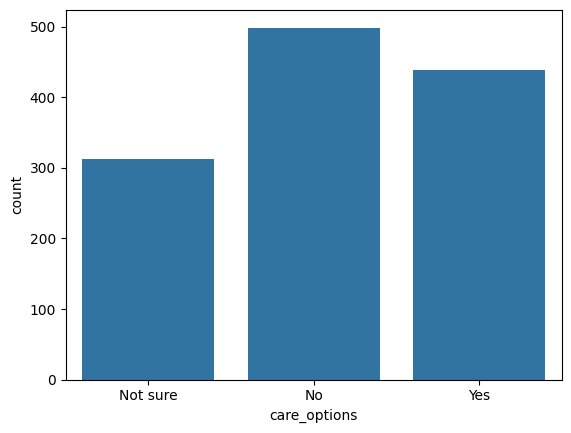

In [63]:
sns.countplot(x='care_options', data=df)
plt.show()



##### 1. Why did you pick the specific chart?
A count plot visualizes employee awareness of available mental healthcare options, which is essential for enabling informed decision-making about treatment.

##### 2. What is/are the insight(s) found from the chart?
Many employees are uncertain or unaware of available care options, indicating a significant gap in communication and resource accessibility.

##### 3. Will the gained insights help creating a positive business impact?
Improving awareness and accessibility of care options through communication campaigns, training, and resources increases treatment-seeking rates and improves overall organizational mental health outcomes.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

- Provide mental health benefits
- Promote wellness programs
- Ensure anonymity & privacy
- Improve leave policies
- Encourage open communication
- Train managers for mental health awareness

# **Conclusion**

This project successfully analyzed mental health trends in the tech industry and identified key factors influencing treatment behavior. The analysis revealed that family history, workplace support, and organizational culture significantly impact employees’ willingness to seek help.

The findings highlight the importance of creating a supportive work environment where employees feel safe discussing mental health issues. Companies that provide benefits, encourage openness, and ensure privacy tend to have healthier employees and better productivity.

Overall, this project demonstrates how data-driven insights can help organizations improve employee well-being and reduce mental health stigma in the workplace.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***